# ML debiasing of the forecast toward ERA5-Land — all 4 variables

**Goal.** Learn a correction that maps the served **IFS-HRES forecast** values
*onto the ERA5-Land archive scale*, so a recent/forecast day (served from HRES)
is comparable to the historical ERA5-Land climatology the percentiles are built
on. We debias **forecast → ERA5-Land** (ERA5-Land is the reference).

> **Direction note (this inverts the original stub).** Target is
> `correction = era5 − hres`; `corrected = hres + correction`. The input level
> feature is the **HRES value** — the thing we actually have at serving time.
> Using `era5` as a feature would be target leakage (we don't have it for a
> recent day). The stub corrected the other way and used `era5` as a feature.

**Four variables, both tails each.** We fit a separate debiaser per variable:
`tmax_C, tmin_C, precip_mm, wind_max_ms`. In every one, **both extremes matter
equally** (hot/cold, dry/wet, calm/gale) and the **center matters but less**.

**Three models** (per variable):
1. **M1 baseline** — subtract the mean bias per **cell × season**.
2. **M2 CatBoost** — geo/seasonal/version features (no cell identity).
3. **M3 CatBoost + cell** — M2 plus `cell` as a native categorical.

**Tail strategy (see §4 + §11).** A uniform **rank-based extremity** weight
within `cell × season`: median rows weight 1, the most extreme rows ≈ `1+ALPHA`×
(ALPHA=1 → 2×, honoring *"1° at the tails ≳ 2° at the median"*). Rank-based (not
z-score) so it treats the skewed/zero-inflated precip & wind tails correctly on
**both** sides. Evaluation is **decile-stratified**; the headline metric is the
average MAE over the two tail deciles.

**Data (cell-agnostic).** ERA5-Land truth from `data/archive-overlap/`, HRES from
`data/hres-forecast/`, both keyed by the snapped **cell-center** coords. We use
whatever cells are present in *both* dirs right now (downloads are ongoing).

In [23]:
import json, time, random, math
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor, Pool

BIAS_DIR  = Path('.').resolve()              # scripts/bias_study (notebook cwd)
REPO      = BIAS_DIR.parents[1]
CELLS_CSV = REPO / 'data' / 'cells.csv'
ARC_DIR   = BIAS_DIR / 'data' / 'archive-overlap'   # ERA5-Land truth
HRES_DIR  = BIAS_DIR / 'data' / 'hres-forecast'      # IFS-HRES forecast
LEDGER    = HRES_DIR / '.hres_progress.json'
ELEV      = BIAS_DIR / 'data' / 'cell_elevation.csv'

# --- variables: both extremes count in every one; center counts but less ---
VARS = [
    {'name': 'tmax',   'col': 'tmax_C',      'unit': '°C',  'nonneg': False},
    {'name': 'tmin',   'col': 'tmin_C',      'unit': '°C',  'nonneg': False},
    {'name': 'precip', 'col': 'precip_mm',   'unit': 'mm',  'nonneg': True},
    {'name': 'wind',   'col': 'wind_max_ms', 'unit': 'm/s', 'nonneg': True},
]
VALUE_COLS = [v['col'] for v in VARS]

# --- knobs ---
ALPHA      = 1.0     # most-extreme row gets (1+ALPHA)x the median row's weight (2x)
CELL_LIMIT = 500     # random sample of available cells; None = use ALL of them
SEED       = 0
ITERS      = 450     # CatBoost trees (bump to ~800 for the full run)

# --- split: blocked-in-time so EVERY season lands in both train and test for
#     every cell (a plain "most-recent 20%" holdout would test only one season
#     and couldn't score the hot/cold tails). Whole time-blocks go to test; an
#     embargo drops train rows touching a test block to stop adjacent-day leakage.
BLOCK_FREQ    = 'M'  # block unit: 'M' (month) or '2W' (two weeks)
HOLDOUT_EVERY = 5    # every Nth block -> test (~1/N of the data, spread across seasons)
EMBARGO_DAYS  = 3    # drop train rows within this many days of any test block

# --- Open-Meteo `ecmwf_ifs` forecast-model version (researched IFS changeovers
#     inside the 2024-03-01-> archive window). Used as a categorical feature. ---
FC_CHANGES = [(pd.Timestamp('2026-05-12'), '50r1'),   # IFS Cycle 50r1
              (pd.Timestamp('2024-11-12'), '49r1')]   # IFS Cycle 49r1
FC_BASE = '48r1'                                       # before 2024-11-12 (cycle 48r1)
# (Open-Meteo open-data IFS also went 0.4°->0.25° on 2024-02-01, but that's before
#  our 2024-03-01 floor, so it is constant in-window and not a useful feature here.)

def snap(coord): return round(coord * 10) / 10
def key_of(lat, lon): return f'{snap(lat):.1f}_{snap(lon):.1f}'
print('paths ok:', ARC_DIR.exists(), HRES_DIR.exists(), LEDGER.exists(), ELEV.exists())

paths ok: True True True True


## 1. Cell-agnostic discovery

Use the **intersection** of the files actually present in both dirs (so the set
grows automatically as more cells download). Optionally take a **random** sample
(not the first-N — those are geographically clustered) for a faster study run.

In [24]:
def haversine_km(lat1, lon1, lat2, lon2):
    EARTH_RADIUS_KM = 6371.0088
    lat1_rad, lat2_rad = np.radians(lat1), np.radians(lat2)
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    chord = np.sin(dlat/2)**2 + np.cos(lat1_rad)*np.cos(lat2_rad)*np.sin(dlon/2)**2
    return 2 * EARTH_RADIUS_KM * np.arcsin(np.sqrt(chord))

archive_keys = {path.name.removeprefix('archive_').removesuffix('.csv.gz')
                for path in ARC_DIR.glob('archive_*.csv.gz')}
hres_keys    = {path.name.removeprefix('hres_').removesuffix('.csv.gz')
                for path in HRES_DIR.glob('hres_*.csv.gz')}
cell_keys = sorted(archive_keys & hres_keys)
print(f'archive={len(archive_keys)}  hres={len(hres_keys)}  usable intersection={len(cell_keys)}')
if CELL_LIMIT and CELL_LIMIT < len(cell_keys):
    cell_keys = random.Random(SEED).sample(cell_keys, CELL_LIMIT)
    print(f'random sample -> {len(cell_keys)} cells')

ledger = json.load(open(LEDGER))['done']     # key -> {name, hres_lat, hres_lon, hres_elevation, ...}
cells  = pd.read_csv(CELLS_CSV)
cells['key'] = [key_of(lat, lon) for lat, lon in zip(cells.lat, cells.lon)]
cells = cells.drop_duplicates('key').merge(pd.read_csv(ELEV), on='cell_id', how='left')
cell_meta_by_key = cells.set_index('key')

rows = []
for key in cell_keys:
    meta = ledger.get(key)
    if meta is None:                              # have files but no ledger meta -> skip
        continue
    lat_str, lon_str = key.split('_')
    cell_meta = cell_meta_by_key.loc[key] if key in cell_meta_by_key.index else None
    rows.append({'key': key, 'lat': float(lat_str), 'lon': float(lon_str),
                 'hres_lat': meta['hres_lat'], 'hres_lon': meta['hres_lon'],
                 'hres_elevation': meta['hres_elevation'],
                 'elevation': (cell_meta['elevation'] if cell_meta is not None else np.nan)})
cell_features = pd.DataFrame(rows)
cell_features['dist_to_hres_km'] = haversine_km(cell_features.lat, cell_features.lon,
                                                cell_features.hres_lat, cell_features.hres_lon)
cell_features['elev_diff_m']     = cell_features['elevation'] - cell_features['hres_elevation']
print(f'static features for {len(cell_features)} cells | elevation NaN: {int(cell_features.elevation.isna().sum())}')
cell_features.head()

archive=5592  hres=6148  usable intersection=5592
random sample -> 500 cells
static features for 500 cells | elevation NaN: 0


,key,lat,lon,hres_lat,hres_lon,hres_elevation,elevation,dist_to_hres_km,elev_diff_m
0,3.6_98.5,3.6,98.5,3.620387,98.467150,34.0,41.1,4.292846,7.1
1,31.2_120.7,31.2,120.7,31.177504,120.713440,3.0,1.6,2.809215,-1.4
2,-26.5_27.9,-26.5,27.9,-26.537786,27.883131,1553.0,1551.5,4.524445,-1.5
3,24.5_88.1,24.5,88.1,24.499120,88.076930,21.0,20.9,2.336355,-0.1
4,36.0_103.9,36.0,103.9,36.028120,103.873055,1953.0,1871.1,3.956045,-81.9


## 2. Load all four variables and join HRES↔ERA5-Land per day

Inner join on `date` keeps only the overlap window (drops the recent HRES-only
tail that has no ERA5-Land truth yet — that's exactly the serving case we can't
score). Read in parallel since it's thousands of small gzips.

In [25]:
def load_cell(key):
    archive = pd.read_csv(ARC_DIR / f'archive_{key}.csv.gz').rename(
        columns={col: f'era5_{col}' for col in VALUE_COLS})
    forecast = pd.read_csv(HRES_DIR / f'hres_{key}.csv.gz').rename(
        columns={col: f'hres_{col}' for col in VALUE_COLS})
    joined = archive.merge(forecast, on='date', how='inner')
    joined['key'] = key
    return joined

start_time = time.time()
with ThreadPoolExecutor(max_workers=8) as pool:
    cell_frames = list(pool.map(load_cell, cell_features.key.tolist()))
df = pd.concat(cell_frames, ignore_index=True).merge(cell_features, on='key', how='left')
df['date'] = pd.to_datetime(df['date'])
# Coerce value cols to numeric: empty/coastal cells read as Arrow strings under
# pandas 3.0 and poison the column to object on concat. Blanks -> NaN (dropped later).
for source in ('era5', 'hres'):
    for col in VALUE_COLS:
        df[f'{source}_{col}'] = pd.to_numeric(df[f'{source}_{col}'], errors='coerce')
# Match prod's precip trace clamp (frontend/src/services/tieredData.ts, PRECIP_TRACE_MM=1): values < 1mm count as 0mm everywhere in the app. Apply identically to both sides before any bias/decile calc.
PRECIP_TRACE_MM = 1
for source in ('era5', 'hres'):
    precip_col = f'{source}_precip_mm'
    df.loc[df[precip_col] < PRECIP_TRACE_MM, precip_col] = 0.0
print(f'long frame {df.shape}  dates {df.date.min().date()}..{df.date.max().date()}  '
      f'({time.time()-start_time:.1f}s)')

long frame (386410, 18)  dates 2024-03-01..2026-05-01  (12.1s)


## 3. Shared features — seasonal phase + forecast-model version

`cos_doy`/`sin_doy` resolve the seasonal cycle (a lone cosine can't tell spring
from autumn). `fc_version` tags each day with the ECMWF IFS cycle Open-Meteo's
archive was on (the changeover dates from §0) — a categorical feature so the
model can absorb a version-dependent offset.

In [26]:
day_of_year = df['date'].dt.dayofyear
df['cos_doy'] = np.cos(2*np.pi*day_of_year/365.25)
df['sin_doy'] = np.sin(2*np.pi*day_of_year/365.25)
df['season']  = (df['date'].dt.month % 12 // 3).map({0:'DJF', 1:'MAM', 2:'JJA', 3:'SON'})
fc_version = pd.Series(FC_BASE, index=df.index)
for change_date, cycle_label in FC_CHANGES:  # later changes applied last (override)
    fc_version = fc_version.mask(df['date'] >= change_date, cycle_label)
df['fc_version'] = fc_version
print(df['fc_version'].value_counts().to_string())

fc_version
49r1    261482
48r1    124928


## 4. Per-variable target, extremity weights & deciles — the tail strategy

For each variable, within every `cell × season`:

- `u` = empirical percentile rank of the **ERA5-Land truth** value.
- `tail = |2·(u − 0.5)|` → **0 at the median, →1 at either extreme** (symmetric,
  so both tails count equally).
- training weight `w = 1 + ALPHA·tail` → median row 1×, most-extreme ≈ 2×.
- decile label `dec`: `low` (driest/coldest/calmest 10%), `high` (top 10%), else `mid`.
- **1%-tail label `dec1`**: `p01` (bottom 1%), `p99` (top 1%), else `mid` — the
  same idea as the deciles but at the genuine extremes (rarest hot/cold, dry/wet,
  calm/gale days). Reported alongside the 10% tails so we can see whether the
  correction holds up at 1-in-100 days, not just 1-in-10.
- target `bias = era5 − hres` (the additive correction to learn).

Rank-based (not z-score) is deliberate: precip/wind are skewed and zero-inflated,
so a z-score would mis-rank the tails; ranks put the genuine dry **and** wet (or
cold **and** hot) extremes in the tail buckets on both sides.

In [27]:
for var in VARS:
    var_name, col = var['name'], var['col']
    pct_rank = df.groupby(['key', 'season'])[f'era5_{col}'].rank(method='average', pct=True)
    tail_strength = (2*(pct_rank - 0.5)).abs()
    df[f'tail_{var_name}'] = tail_strength
    df[f'w_{var_name}']    = 1 + ALPHA*tail_strength
    df[f'dec_{var_name}']  = np.where(pct_rank <= 0.1, 'low', np.where(pct_rank >= 0.9, 'high', 'mid'))
    df[f'dec1_{var_name}'] = np.where(pct_rank <= 0.01, 'p01', np.where(pct_rank >= 0.99, 'p99', 'mid'))  # 1% tails
    df[f'bias_{var_name}'] = df[f'era5_{col}'] - df[f'hres_{col}']
print('weight range:', round(df['w_tmax'].min(),2), '..', round(df['w_tmax'].max(),2))
df[['key','date','season','era5_tmax_C','hres_tmax_C','bias_tmax','tail_tmax','w_tmax','dec_tmax','dec1_tmax']].head()

weight range: 1.0 .. 2.0


,key,date,season,era5_tmax_C,hres_tmax_C,bias_tmax,tail_tmax,w_tmax,dec_tmax,dec1_tmax
0,3.6_98.5,2024-03-01,MAM,30.319000,32.4,-2.081000,0.386179,1.386179,mid,mid
1,3.6_98.5,2024-03-02,MAM,29.131001,30.0,-0.868999,0.560976,1.560976,mid,mid
2,3.6_98.5,2024-03-03,MAM,30.163000,31.5,-1.337000,0.272358,1.272358,mid,mid
3,3.6_98.5,2024-03-04,MAM,30.256001,31.8,-1.543999,0.349593,1.349593,mid,mid
4,3.6_98.5,2024-03-05,MAM,27.256001,31.1,-3.843999,0.943089,1.943089,low,mid


## 5. Split — blocked in time (all seasons in both train & test)

A naïve "hold out the most-recent 20% of dates" is wrong for a **tail** objective:
the test set would cover only one season, so the hot tail (summer) or cold tail
(winter) could sit entirely in train and never be scored. Instead we block the
timeline (monthly by default) and send **every Nth whole block** to test. Whole
blocks (not random rows) avoid the adjacent-day leakage — a cell's consecutive
days share almost the same bias — and an **embargo** drops train rows within a few
days of a test block so nothing leaks across the seam. The coverage table below
confirms all four seasons appear in **both** splits.

This is fair to all three models (M1's cell×season means and M3's `cell` feature
are populated from training rows that now span every season). Generalization to
**unseen cells** is the separate question in §10.

In [28]:
origin_date = df['date'].min().normalize()
if BLOCK_FREQ == 'M':
    block_id = (df['date'].dt.year - origin_date.year) * 12 + (df['date'].dt.month - origin_date.month)
else:                                              # '2W' -> 14-day blocks
    block_id = (df['date'] - origin_date).dt.days // 14
all_blocks = np.unique(block_id)
test_blocks = set(all_blocks[::HOLDOUT_EVERY])
df['is_test'] = block_id.isin(test_blocks)
# embargo: a train row is dropped if within EMBARGO_DAYS of any test-block date
test_dates = pd.DatetimeIndex(np.unique(df.loc[df['is_test'], 'date']))
embargoed_dates = test_dates
for offset in range(1, EMBARGO_DAYS + 1):
    embargoed_dates = embargoed_dates.union(test_dates + pd.Timedelta(days=offset)).union(test_dates - pd.Timedelta(days=offset))
df['is_train'] = (~df['is_test']) & (~df['date'].isin(embargoed_dates))
print(f'{BLOCK_FREQ} blocks: {len(all_blocks)} total -> {len(test_blocks)} test  (embargo {EMBARGO_DAYS}d)')
print(f'train rows {int(df.is_train.sum()):,}   test rows {int(df.is_test.sum()):,}   '
      f'(dropped to embargo: {int((~df.is_train & ~df.is_test).sum()):,})')
print('season coverage (rows in each split):')
print(df.groupby("season").agg(train=("is_train","sum"), test=("is_test","sum")).to_string())

M blocks: 27 total -> 6 test  (embargo 3d)
train rows 282,064   test rows 89,304   (dropped to embargo: 15,042)
season coverage (rows in each split):
        train   test
season              
DJF     68320  15128
JJA     57096  29768
MAM     85400  29768
SON     71248  14640


## 6. The three models + the evaluator

`evaluate()` applies a predicted correction (clipped ≥0 for precip/wind), then
reports MAE per decile + mean residual bias per decile. Passing a zero prediction
gives the **raw** (do-nothing) baseline — the bar every model must beat.

In [29]:
GEO_FEATURES      = ['elevation', 'hres_elevation', 'elev_diff_m', 'dist_to_hres_km', 'lat', 'lon']
SEASONAL_FEATURES = ['cos_doy', 'sin_doy']
def hres_col(var_name): return f"hres_{next(var['col'] for var in VARS if var['name']==var_name)}"
def era5_col(var_name): return f"era5_{next(var['col'] for var in VARS if var['name']==var_name)}"
def feature_cols(var_name, with_cell):
    return [hres_col(var_name)] + GEO_FEATURES + SEASONAL_FEATURES + ['fc_version'] + (['key'] if with_cell else [])

def fit_baseline(train, var_name):
    return (train.groupby(['key','season'])[f'bias_{var_name}'].mean(),  # per cell+season
            train.groupby('season')[f'bias_{var_name}'].mean(),          # per season
            train[f'bias_{var_name}'].mean())                            # global fallback

def pred_baseline(test, models):
    cell_season_mean, season_mean, global_mean = models
    pred = cell_season_mean.reindex(list(zip(test['key'], test['season']))).to_numpy()
    pred = np.where(np.isnan(pred), season_mean.reindex(test['season']).to_numpy(), pred)
    return np.where(np.isnan(pred), global_mean, pred)

def fit_catboost(train, var_name, with_cell):
    cat_features = ['fc_version'] + (['key'] if with_cell else [])
    pool = Pool(train[feature_cols(var_name, with_cell)], train[f'bias_{var_name}'],
                cat_features=cat_features, weight=train[f'w_{var_name}'].to_numpy())
    model = CatBoostRegressor(iterations=ITERS, depth=6, learning_rate=0.05,
                              loss_function='MAE', l2_leaf_reg=3.0,
                              random_seed=SEED, verbose=False)
    model.fit(pool)
    return model

def evaluate(test, var_name, pred, nonneg):
    corrected = test[hres_col(var_name)].to_numpy() + np.asarray(pred)
    if nonneg:
        corrected = np.clip(corrected, 0, None)
    residual = test[era5_col(var_name)].to_numpy() - corrected
    decile = test[f'dec_{var_name}'].to_numpy()
    decile_mask = {'low': decile=='low', 'mid': decile=='mid', 'high': decile=='high'}
    mae  = {name: float(np.abs(residual[mask]).mean()) for name, mask in decile_mask.items()}
    bias = {name: float(residual[mask].mean())          for name, mask in decile_mask.items()}
    # 1% extreme tails (p01 = bottom 1%, p99 = top 1%) — same idea as the deciles
    tail_pctile = test[f'dec1_{var_name}'].to_numpy()
    for pctile_label, out_key in (('p01', 'low1'), ('p99', 'high1')):
        mask = tail_pctile == pctile_label
        mae[out_key]  = float(np.abs(residual[mask]).mean()) if mask.any() else float('nan')
        bias[out_key] = float(residual[mask].mean())          if mask.any() else float('nan')
    mae['all']   = float(np.abs(residual).mean())
    mae['tail']  = 0.5*(mae['low']  + mae['high'])    # headline: both 10% tails, equal
    mae['tail1'] = 0.5*(mae['low1'] + mae['high1'])   # both 1% tails, equal
    return {'mae': mae, 'bias': bias}

## 7. Train + evaluate every variable × model

In [30]:
import pickle
MODELS = BIAS_DIR / 'models'; MODELS.mkdir(exist_ok=True)
RETRAIN = False     # False = load cached models if present; True = force a fresh fit + overwrite cache

# Models are specific to the cell-sample + seed they were trained on. Encode that
# in the filename (e.g. M3_tmax_n500_s0.cbm) and write a spec.json so the exact run
# is reproducible — including the literal cell list, since the random sample shifts
# as more cells finish downloading even at a fixed SEED.
NCELLS = int(df['key'].nunique())
TAG    = f'n{NCELLS}_s{SEED}'
def model_paths(var_name):
    return (MODELS/f'M1_{var_name}_{TAG}.pkl', MODELS/f'M2_{var_name}_{TAG}.cbm', MODELS/f'M3_{var_name}_{TAG}.cbm')
def is_cached(var_name):
    return all(path.exists() for path in model_paths(var_name))
def save_models(var_name, baseline_model, cat_model, cat_cell_model):
    baseline_path, cat_path, cat_cell_path = model_paths(var_name)
    with open(baseline_path, 'wb') as f: pickle.dump(baseline_model, f)   # M1 = (cell-season means, season means, global)
    cat_model.save_model(str(cat_path)); cat_cell_model.save_model(str(cat_cell_path))
def load_models(var_name):
    baseline_path, cat_path, cat_cell_path = model_paths(var_name)
    with open(baseline_path, 'rb') as f: baseline_model = pickle.load(f)
    cat_model = CatBoostRegressor(); cat_model.load_model(str(cat_path))
    cat_cell_model = CatBoostRegressor(); cat_cell_model.load_model(str(cat_cell_path))
    return baseline_model, cat_model, cat_cell_model

results = {}          # results[var] = {'raw':eval, 'M1 mean':eval, 'M2 cat':eval, 'M3 cat+cell':eval}
start_time = time.time()
for var in VARS:
    var_name, nonneg = var['name'], var['nonneg']
    var_df = df.dropna(subset=[f'bias_{var_name}', f'w_{var_name}'])
    train, test = var_df[var_df.is_train], var_df[var_df.is_test]
    if (not RETRAIN) and is_cached(var_name):
        baseline_model, cat_model, cat_cell_model = load_models(var_name); status = 'loaded cache'
    else:
        baseline_model = fit_baseline(train, var_name)
        cat_model      = fit_catboost(train, var_name, with_cell=False)
        cat_cell_model = fit_catboost(train, var_name, with_cell=True)
        save_models(var_name, baseline_model, cat_model, cat_cell_model); status = 'trained + saved'
    results[var_name] = {
        'raw':         evaluate(test, var_name, np.zeros(len(test)), nonneg),
        'M1 mean':     evaluate(test, var_name, pred_baseline(test, baseline_model), nonneg),
        'M2 cat':      evaluate(test, var_name, cat_model.predict(test[feature_cols(var_name, False)]), nonneg),
        'M3 cat+cell': evaluate(test, var_name, cat_cell_model.predict(test[feature_cols(var_name, True)]), nonneg),
    }
    results[var_name]['_models'] = {'M1 mean': baseline_model, 'M2 cat': cat_model, 'M3 cat+cell': cat_cell_model}  # all 3 kept in memory
    print(f'  {var_name:6s} {status}')

# reproducibility spec for this exact run (knobs + the literal cell list)
spec = {'tag': TAG, 'cell_limit': CELL_LIMIT, 'seed': SEED, 'n_cells': NCELLS,
        'iters': ITERS, 'alpha': ALPHA, 'block_freq': BLOCK_FREQ,
        'holdout_every': HOLDOUT_EVERY, 'embargo_days': EMBARGO_DAYS,
        'date_min': str(df.date.min().date()), 'date_max': str(df.date.max().date()),
        'n_rows': int(len(df)), 'trained_at': time.strftime('%Y-%m-%d %H:%M:%S'),
        'cells': sorted(df['key'].unique().tolist())}
with open(MODELS / f'spec_{TAG}.json', 'w') as f:
    json.dump(spec, f, indent=1)
print(f'4 vars x 3 models in {time.time()-start_time:.0f}s  (RETRAIN={RETRAIN})')
print(f'cache + spec -> {MODELS}  | tag={TAG}  ({NCELLS} cells, seed {SEED})')

# headline table: tail MAE at the 10% and 1% tails vs raw, + overall MAE
headline_rows = []
for var in VARS:
    var_name, unit = var['name'], var['unit']
    raw_mae = results[var_name]['raw']['mae']
    for model_name in ['M1 mean', 'M2 cat', 'M3 cat+cell']:
        model_mae = results[var_name][model_name]['mae']
        headline_rows.append({'var': f'{var_name} ({unit})', 'model': model_name,
                      'raw_tailMAE': raw_mae['tail'], 'tailMAE': model_mae['tail'],
                      'tail_impr_%': 100*(1 - model_mae['tail']/raw_mae['tail']),
                      'raw_tail1MAE': raw_mae['tail1'], 'tail1MAE': model_mae['tail1'],
                      'tail1_impr_%': 100*(1 - model_mae['tail1']/raw_mae['tail1']),
                      'raw_MAE': raw_mae['all'], 'MAE': model_mae['all'],
                      'all_impr_%': 100*(1 - model_mae['all']/raw_mae['all'])})
headline = pd.DataFrame(headline_rows)
print('\n== headline: tailMAE = mean(10% low+high); tail1MAE = mean(1% low+high); both tails equal ==')
print(headline.round(3).to_string(index=False))

  tmax   loaded cache
  tmin   loaded cache
  precip loaded cache
  wind   loaded cache
4 vars x 3 models in 2s  (RETRAIN=False)
cache + spec -> /home/ita/HowHotWasIt/scripts/bias_study/models  | tag=n488_s0  (488 cells, seed 0)

== headline: tailMAE = mean(10% low+high); tail1MAE = mean(1% low+high); both tails equal ==
        var       model  raw_tailMAE  tailMAE  tail_impr_%  raw_tail1MAE  tail1MAE  tail1_impr_%  raw_MAE   MAE  all_impr_%
  tmax (°C)     M1 mean        1.228    0.895       27.084         1.287     1.018        20.891    1.167 0.797      31.699
  tmax (°C)      M2 cat        1.228    0.907       26.164         1.287     1.062        17.463    1.167 0.783      32.915
  tmax (°C) M3 cat+cell        1.228    0.880       28.324         1.287     1.047        18.679    1.167 0.757      35.178
  tmin (°C)     M1 mean        1.196    0.925       22.664         1.325     1.094        17.441    1.105 0.812      26.554
  tmin (°C)      M2 cat        1.196    0.934       21.87

## 8. Plots — does the correction help **at the tails**?

Left: MAE in the low / mid / high decile, raw vs each model — the bars over `low`
and `high` are what we care about most. Right: mean residual **bias** per decile
(raw vs best model); flat-at-zero across all three buckets = well-calibrated in
both tails and the center.

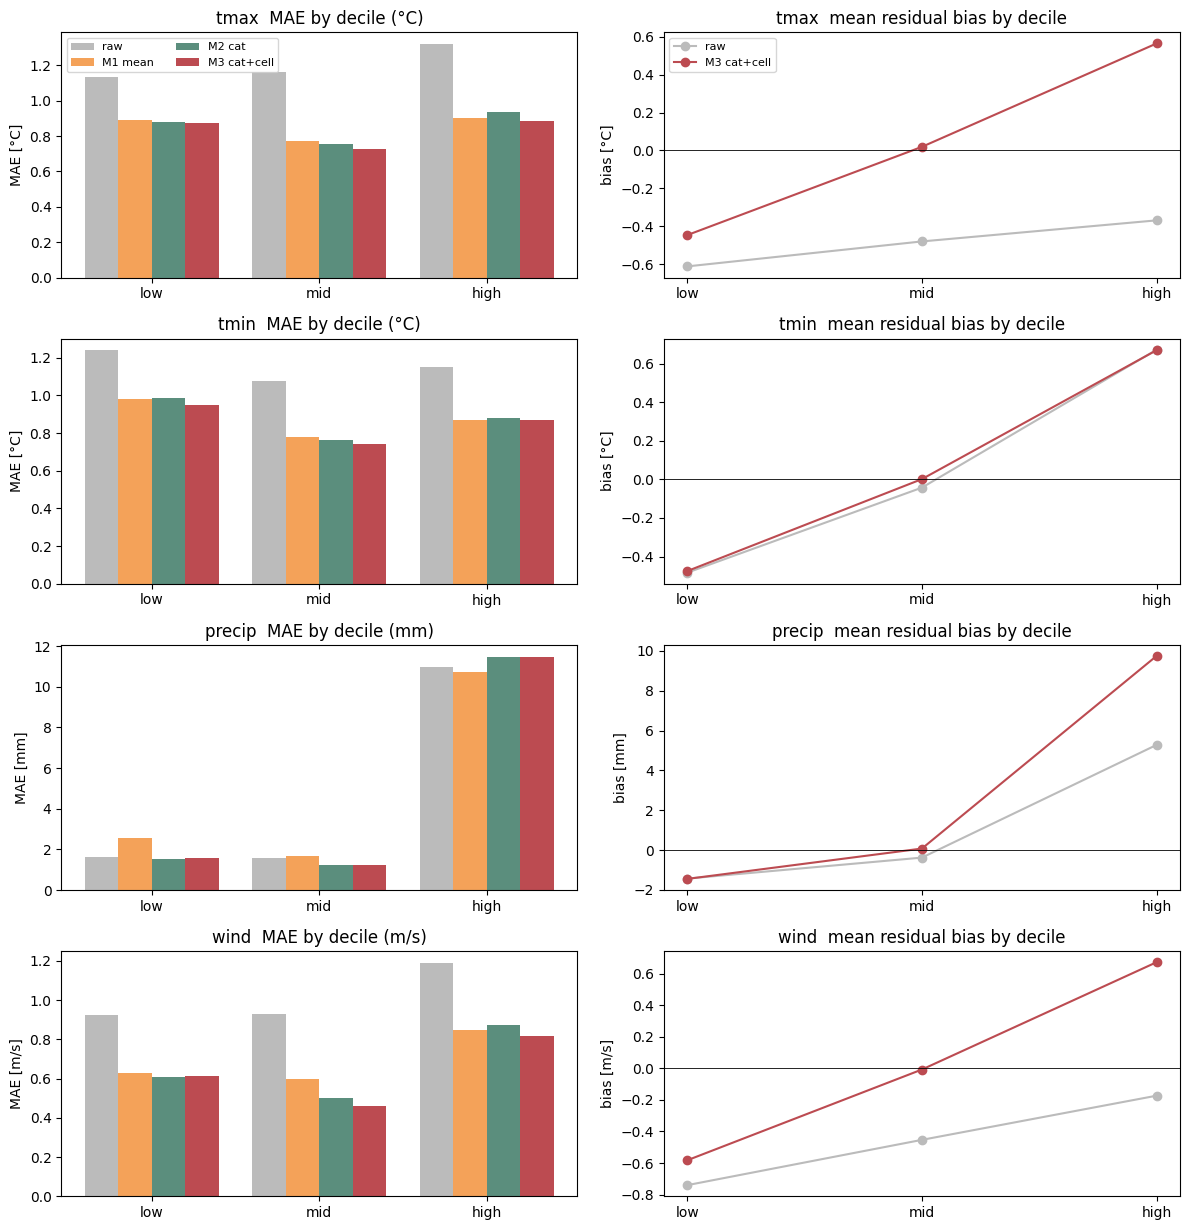

In [31]:
deciles = ['low', 'mid', 'high']
model_names = ['raw', 'M1 mean', 'M2 cat', 'M3 cat+cell']
colors = {'raw':'#bbb', 'M1 mean':'#f4a259', 'M2 cat':'#5b8e7d', 'M3 cat+cell':'#bc4b51'}
fig, axes = plt.subplots(len(VARS), 2, figsize=(12, 3.1*len(VARS)))
for var_idx, var in enumerate(VARS):
    var_name, unit = var['name'], var['unit']
    ax_mae, ax_bias = axes[var_idx]
    x = np.arange(3); bar_width = 0.2
    for model_idx, model_name in enumerate(model_names):
        mae = results[var_name][model_name]['mae']
        ax_mae.bar(x + (model_idx-1.5)*bar_width, [mae[d] for d in deciles], bar_width, label=model_name, color=colors[model_name])
    ax_mae.set_xticks(x); ax_mae.set_xticklabels(deciles)
    ax_mae.set_title(f'{var_name}  MAE by decile ({unit})'); ax_mae.set_ylabel(f'MAE [{unit}]')
    if var_idx == 0: ax_mae.legend(fontsize=8, ncol=2)
    for model_name in ['raw', 'M3 cat+cell']:
        bias = results[var_name][model_name]['bias']
        ax_bias.plot(deciles, [bias[d] for d in deciles], 'o-', label=model_name, color=colors[model_name])
    ax_bias.axhline(0, color='k', lw=0.6); ax_bias.set_title(f'{var_name}  mean residual bias by decile')
    ax_bias.set_ylabel(f'bias [{unit}]');
    if var_idx == 0: ax_bias.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 9. Diagnostics — version offset & feature importance

In [32]:
# raw HRES bias by forecast-model version (sanity on the version feature)
print('mean raw bias (era5 - hres) by fc_version:')
print(df.groupby('fc_version')[[f'bias_{var["name"]}' for var in VARS]].mean().round(3).to_string())

# feature importance for the M3 model of each variable
print('\nM3 feature importance (top 5 per variable):')
for var in VARS:
    model = results[var['name']]['_models']['M3 cat+cell']
    importance = pd.Series(model.get_feature_importance(), index=feature_cols(var['name'], True)).sort_values(ascending=False)
    print(f"  {var['name']:6s}: " + ', '.join(f'{feat}={score:.0f}' for feat, score in importance.head(5).items()))

mean raw bias (era5 - hres) by fc_version:
            bias_tmax  bias_tmin  bias_precip  bias_wind
fc_version                                              
48r1           -0.507      0.126       -0.050     -0.662
49r1           -0.524     -0.128        0.112     -0.355

M3 feature importance (top 5 per variable):
  tmax  : key=39, hres_tmax_C=17, lat=12, lon=7, sin_doy=4
  tmin  : key=35, hres_tmin_C=14, lat=12, lon=8, elev_diff_m=7
  precip: hres_precip_mm=71, key=7, lat=6, lon=6, cos_doy=3
  wind  : key=39, hres_wind_max_ms=26, lon=8, lat=7, fc_version=5


## 9b. The error *tail* — what a big miss looks like, and where/when to expect it

Not cell averages. We look at the **distribution of the per-day errors** on the
test set — `err = era5 − value` for every cell×day — and zoom into its tail. We
carry **both** CatBoost models through, because the tail is exactly where they can
diverge: **M2 cat** uses every feature *except* the cell identity (geo, season,
forecast version), while **M3 cat+cell** adds the cell `key` as a categorical.
Comparing the two shows how much of the tail correction comes from knowing the
*specific cell* versus the general signal.

1. **What a high error looks like.** Tail percentiles of `|error|` (p50 → p99.9 →
   max), raw vs M2 vs M3-corrected, plus a **histogram** of all signed errors per
   metric. "A 1-in-100 bad day for tmax is ≥ X °C; the worst was Y °C." This sets a
   concrete `THR` = 99th-pctile of raw `|error|` per variable = our **big miss**.
2. **Concrete worst events.** The literal 12 largest single day×cell misses per
   variable — date, cell, lat/lon, season, the era5 truth, the served hres value,
   the M2- and M3-corrected values, and the signed error before/after. The
   *what / where / when* in one table.
3. **When.** Of all big-miss days, how they split by **season** and by
   value-**decile** — and whether M2 / M3 reduce *how many* big-miss days there are.
4. **Where.** Per cell: its worst single day, its `|error|` p99, and its count of
   big-miss days (raw vs after M2 vs after M3). Mapped, so the geography of the
   extremes is visible.
5. **Q-Q (worst cells).** For the cells with the most big-miss days, quantile-quantile
   plots of forecast vs ERA5 truth — raw, M2- and M3-corrected against the 45° line.
   Shows *how* the forecast distribution is biased at the tails (e.g. precip clipping
   heavy rain) and whether the models pull it onto the diagonal.

In [ ]:
# Per-day test errors for raw (do-nothing) vs M2 cat vs M3 cat+cell. We keep every
# row's SIGNED error (era5 - value) and work with the distribution, not cell averages.
# M2 = CatBoost minus the cell key; M3 adds it -- carrying both shows how much of the
# tail fix actually needs the specific cell.
MODELS_9B = {'M2': 'M2 cat', 'M3': 'M3 cat+cell'}     # short label -> results['_models'] key
errors_by_var, big_miss_threshold = {}, {}
for var in VARS:
    var_name, nonneg = var['name'], var['nonneg']
    test = df[df.is_test].dropna(subset=[f'bias_{var_name}', f'w_{var_name}']).copy()
    test['err_raw'] = test[era5_col(var_name)].to_numpy() - test[hres_col(var_name)].to_numpy()
    test['ae_raw']  = test['err_raw'].abs()
    for short, model_key in MODELS_9B.items():
        with_cell = (model_key == 'M3 cat+cell')
        corrected = test[hres_col(var_name)].to_numpy() + \
            results[var_name]['_models'][model_key].predict(test[feature_cols(var_name, with_cell)])
        if nonneg:
            corrected = np.clip(corrected, 0, None)
        test[short]          = corrected                                    # 'M2'/'M3' corrected value
        test[f'err_{short}'] = test[era5_col(var_name)].to_numpy() - corrected
        test[f'ae_{short}']  = test[f'err_{short}'].abs()
    test['month'] = test['date'].dt.month
    errors_by_var[var_name] = test
    big_miss_threshold[var_name] = float(test['ae_raw'].quantile(0.99))

# Histogram of ALL signed errors per metric: raw (filled) vs M2 / M3 (step outlines),
# on a log count axis so the tails are visible. Dashed lines = +/- the raw 99th-pctile
# |error| (the big-miss cut).
model_color = {'raw': '#bbb', 'M2': '#5b8e7d', 'M3': '#bc4b51'}
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, var in zip(axes.ravel(), VARS):
    var_name, unit = var['name'], var['unit']
    test = errors_by_var[var_name]
    err_cols = ['err_raw', 'err_M2', 'err_M3']
    lo_edge = float(min(test[c].quantile(0.002) for c in err_cols))
    hi_edge = float(max(test[c].quantile(0.998) for c in err_cols))
    bins = np.linspace(lo_edge, hi_edge, 80)
    ax.hist(test['err_raw'].clip(lo_edge, hi_edge), bins=bins, color=model_color['raw'], alpha=0.85, label='raw')
    ax.hist(test['err_M2'].clip(lo_edge, hi_edge),  bins=bins, color=model_color['M2'], histtype='step', lw=1.4, label='M2')
    ax.hist(test['err_M3'].clip(lo_edge, hi_edge),  bins=bins, color=model_color['M3'], histtype='step', lw=1.4, label='M3')
    ax.axvline(0, color='k', lw=0.6)
    ax.axvline( big_miss_threshold[var_name], color='#444', ls='--', lw=0.8)
    ax.axvline(-big_miss_threshold[var_name], color='#444', ls='--', lw=0.8)
    ax.set_yscale('log')
    ax.set_title(f'{var_name}: signed error (era5 - value) [{unit}]   THR=±{big_miss_threshold[var_name]:.1f}')
    ax.set_xlabel(f'error [{unit}]'); ax.set_ylabel('days (log)'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# What a "high error" looks like: tail percentiles of |error|, raw vs M2 vs M3.
tail_rows = []
for var in VARS:
    var_name, unit = var['name'], var['unit']
    test = errors_by_var[var_name]
    for pctile_label, quantile in [('p50',.5), ('p90',.9), ('p99',.99), ('p99.9',.999)]:
        tail_rows.append({'var': f'{var_name} ({unit})', 'pctile': pctile_label,
                     'raw_|err|': test['ae_raw'].quantile(quantile),
                     'M2_|err|':  test['ae_M2'].quantile(quantile),
                     'M3_|err|':  test['ae_M3'].quantile(quantile)})
    tail_rows.append({'var': f'{var_name} ({unit})', 'pctile': 'max',
                 'raw_|err|': test['ae_raw'].max(), 'M2_|err|': test['ae_M2'].max(), 'M3_|err|': test['ae_M3'].max()})
print('== |error| tail: the bad days, raw vs M2 vs M3-corrected (not averages) ==')
print(pd.DataFrame(tail_rows).round(2).to_string(index=False))
print('\nbig-miss threshold THR = raw 99th-pctile |error|:',
      {var['name']: round(big_miss_threshold[var['name']], 2) for var in VARS})

In [ ]:
# The literal worst individual day x cell misses (raw), with what M2 and M3 did to
# each. Concrete answer to "what does a high error look like, and where & when".
for var in VARS:
    var_name, unit = var['name'], var['unit']
    test = errors_by_var[var_name]
    cols = ['date','key','lat','lon','season', era5_col(var_name), hres_col(var_name), 'M2', 'M3',
            'err_raw','err_M2','err_M3', f'dec_{var_name}']
    worst = test.nlargest(12, 'ae_raw')[cols].copy()
    worst['date'] = worst['date'].dt.date
    worst = worst.rename(columns={era5_col(var_name):'era5', hres_col(var_name):'hres', f'dec_{var_name}':'decile'})
    print(f'\n=== {var_name} ({unit}) — 12 worst single-day misses (raw |err|) ===')
    print(worst.round(2).to_string(index=False))

# WHEN do big misses (raw |err| >= THR) happen — by season and value-decile — and do
# M2 / M3 cut HOW MANY big-miss days there are?
print('\n' + '='*70)
for var in VARS:
    var_name, unit = var['name'], var['unit']
    test = errors_by_var[var_name]
    big_misses = test[test.ae_raw >= big_miss_threshold[var_name]]
    n_M2 = int((test.ae_M2 >= big_miss_threshold[var_name]).sum())
    n_M3 = int((test.ae_M3 >= big_miss_threshold[var_name]).sum())
    denom = max(len(big_misses), 1)
    print(f'\n{var_name} ({unit}): {len(big_misses)} big-miss days (|err|>={big_miss_threshold[var_name]:.1f}); '
          f'after M2 -> {n_M2} ({100*(1-n_M2/denom):+.0f}%); after M3 -> {n_M3} ({100*(1-n_M3/denom):+.0f}%)')
    print('  by season:', {season:int(count) for season,count in big_misses.groupby("season").size().items()})
    print('  by value-decile:', {decile:int(count) for decile,count in big_misses.groupby(f"dec_{var_name}").size().items()})

In [ ]:
# WHERE the big errors live. Per cell: its worst single day, its |err| p99, and its
# count of big-miss days (raw vs after M2 vs after M3). Listed, then mapped.
for var in VARS:
    var_name, unit = var['name'], var['unit']
    test = errors_by_var[var_name]
    per_cell = test.groupby('key').agg(days=('ae_raw','size'),
                              p99_raw=('ae_raw', lambda errs: errs.quantile(0.99)),
                              max_raw=('ae_raw','max'),
                              lat=('lat','first'), lon=('lon','first'))
    for short in ('raw', 'M2', 'M3'):
        per_cell[f'big_{short}'] = (test[test[f'ae_{short}'] >= big_miss_threshold[var_name]]
                                    .groupby('key').size().reindex(per_cell.index).fillna(0).astype(int))
    top_cells = per_cell.sort_values('max_raw', ascending=False).head(10)
    print(f'\n=== {var_name} ({unit}) — 10 cells with the biggest single-day misses ===')
    print(top_cells.round(2).to_string())

# Map: worst single-day |err| per cell (left), and the change in #big-miss days after
# M2 (middle) and after M3 (right; blue = fewer big misses = the model helps there).
fig, axes = plt.subplots(len(VARS), 3, figsize=(16, 3.0*len(VARS)))
for var_idx, var in enumerate(VARS):
    var_name, unit = var['name'], var['unit']
    test = errors_by_var[var_name]
    per_cell = test.groupby('key').agg(max_raw=('ae_raw','max'), lat=('lat','first'), lon=('lon','first'))
    big_raw = test[test.ae_raw >= big_miss_threshold[var_name]].groupby('key').size().reindex(per_cell.index).fillna(0)
    ax_worst, ax_m2, ax_m3 = axes[var_idx]
    worst_scatter = ax_worst.scatter(per_cell.lon, per_cell.lat, c=per_cell.max_raw, s=10, cmap='magma_r',
                     vmin=0, vmax=per_cell.max_raw.quantile(0.98))
    ax_worst.set_title(f'{var_name}: worst single-day |err| per cell [{unit}]'); fig.colorbar(worst_scatter, ax=ax_worst, shrink=0.8)
    for ax_delta, short in ((ax_m2, 'M2'), (ax_m3, 'M3')):
        big_model = test[test[f'ae_{short}'] >= big_miss_threshold[var_name]].groupby('key').size().reindex(per_cell.index).fillna(0)
        delta = big_model - big_raw                       # negative = fewer big misses after the model
        delta_lim = max(1.0, float(np.abs(delta).quantile(0.98)))
        delta_scatter = ax_delta.scatter(per_cell.lon, per_cell.lat, c=delta, s=10, cmap='RdBu_r', vmin=-delta_lim, vmax=delta_lim)
        ax_delta.set_title(f'{var_name}: change in #big-miss days after {short} (blue=fewer)'); fig.colorbar(delta_scatter, ax=ax_delta, shrink=0.8)
    for ax in (ax_worst, ax_m2, ax_m3):
        ax.set_xlim(-180,180); ax.set_ylim(-90,90); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

In [ ]:
# Q-Q plots for the worst cells per metric: do the forecast's quantiles line up with
# ERA5 truth, and do M2 / M3 pull them onto the diagonal? "Worst" = most big-miss days
# (raw |err| >= THR). Gray = raw hres vs era5; teal = M2-corrected; red = M3-corrected;
# the dashed 45-deg line is perfect agreement. Departure at the ends = tail bias.
quantile_levels = np.linspace(0.02, 0.98, 49)
N_WORST = 3                              # worst cells shown per metric
fig, axes = plt.subplots(len(VARS), N_WORST, figsize=(4*N_WORST, 3.4*len(VARS)))
for var_idx, var in enumerate(VARS):
    var_name, unit = var['name'], var['unit']
    test = errors_by_var[var_name]
    big_by_cell = test[test.ae_raw >= big_miss_threshold[var_name]].groupby('key').size().sort_values(ascending=False)
    worst_keys = big_by_cell.head(N_WORST).index.tolist()
    for col_idx, cell_key in enumerate(worst_keys):
        ax = axes[var_idx, col_idx]
        cell_rows = test[test.key == cell_key]
        truth_q = cell_rows[era5_col(var_name)].quantile(quantile_levels).to_numpy()
        raw_q = cell_rows[hres_col(var_name)].quantile(quantile_levels).to_numpy()
        m2_q  = cell_rows['M2'].quantile(quantile_levels).to_numpy()
        m3_q  = cell_rows['M3'].quantile(quantile_levels).to_numpy()
        lo_val = float(min(truth_q.min(), raw_q.min(), m2_q.min(), m3_q.min()))
        hi_val = float(max(truth_q.max(), raw_q.max(), m2_q.max(), m3_q.max()))
        ax.plot([lo_val, hi_val], [lo_val, hi_val], 'k--', lw=0.7)
        ax.scatter(truth_q, raw_q, s=14, color='#999',    label='raw hres')
        ax.scatter(truth_q, m2_q,  s=14, color='#5b8e7d', label='M2')
        ax.scatter(truth_q, m3_q,  s=14, color='#bc4b51', label='M3')
        ax.set_title(f'{var_name} @ {cell_key}  ({int(big_by_cell[cell_key])} big-miss d)', fontsize=8)
        ax.set_xlabel(f'era5 quantile [{unit}]', fontsize=7)
        ax.set_ylabel(f'forecast quantile [{unit}]', fontsize=7)
        if var_idx == 0 and col_idx == 0:
            ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

## 10. Geographic transfer to **unseen** cells (optional)

The temporal split scores known cells. For the cells still downloading we also
want: does the debiaser generalize to cells it has **never** seen? Hold out whole
cells (`GroupShuffleSplit`). Expect M3's `cell` feature to lose its edge here
(unseen categories fall back to CatBoost's prior) while M2's geo features should
still transfer. Set `RUN_TRANSFER = True` to run (adds training time).

In [37]:
RUN_TRANSFER = False
if RUN_TRANSFER:
    from sklearn.model_selection import GroupShuffleSplit
    splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
    train_idx, test_idx = next(splitter.split(df, groups=df['key']))
    train_cells, test_cells = df.iloc[train_idx], df.iloc[test_idx]
    print(f'cell-holdout: train cells {train_cells.key.nunique()}  test cells {test_cells.key.nunique()}')
    transfer_rows = []
    for var in VARS:
        var_name, nonneg = var['name'], var['nonneg']
        train = train_cells.dropna(subset=[f'bias_{var_name}', f'w_{var_name}'])
        test  = test_cells.dropna(subset=[f'bias_{var_name}'])
        raw = evaluate(test, var_name, np.zeros(len(test)), nonneg)['mae']
        for model_name, with_cell in [('M2 cat', False), ('M3 cat+cell', True)]:
            model = fit_catboost(train, var_name, with_cell=with_cell)
            model_mae = evaluate(test, var_name, model.predict(test[feature_cols(var_name, with_cell)]), nonneg)['mae']
            transfer_rows.append({'var': var_name, 'model': model_name, 'raw_tailMAE': raw['tail'],
                          'tailMAE': model_mae['tail'], 'tail_impr_%': 100*(1-model_mae['tail']/raw['tail'])})
    print(pd.DataFrame(transfer_rows).round(3).to_string(index=False))
else:
    print('RUN_TRANSFER = False (set True to test generalization to unseen cells)')

RUN_TRANSFER = False (set True to test generalization to unseen cells)


## 11. Reading the results, the precip caveat, and shipping

**Tail metric.** `tailMAE = ½(low-decile MAE + high-decile MAE)` weights both
extremes equally; the center (`mid`) is reported but not in the headline. Training
mirrors this via the `w = 1 + ALPHA·tail` sample weights (ALPHA is the knob: 1 →
tails 2× the median, matching *"1° at the tails ≳ 2° at the median"*). To push the
tails harder, raise ALPHA; to also stop the model trading center accuracy away,
watch the `mid` column.

**Temperature (tmax/tmin).** The additive GBT correction should beat the per-cell
mean baseline at the tails, because `hres` (the level) lets it learn a
*level-dependent* bias the constant per-cell offset can't. M3's `cell` feature
adds a per-cell residual on top (only on **seen** cells — see §10).

**Precip caveat (expect this).** Additive debiasing improves precip in the bulk
but often **not at the tails**: IFS over-produces drizzle (dry tail) and clips
heavy-rain peaks (wet tail), a skewed/multiplicative error an additive tree fit
can't undo. If precip tails matter, the right tool is **quantile mapping** (fit
the ERA5↔HRES CDF per cell×season and remap), or a multiplicative/log-space
target — a separate follow-up, not this additive model. Wind sits between temp
and precip.

**Shipping (next step).** If a variable generalizes, persist its M3 model and
apply it in the serving path as `corrected = clip(hres + model.predict(feat), 0…)`
for recent/forecast days, so they land on the ERA5-Land scale the percentiles use.

In [38]:
# Models are already persisted by §7 to `models/` as M1/M2/M3_<var>_<TAG>.cbm|pkl
# (TAG = nCELLS_sSEED), alongside spec_<TAG>.json which records the knobs + the exact
# cell list for reproducibility. To reuse a saved M3 debiaser in the serving path:
#
# from catboost import CatBoostRegressor
# model = CatBoostRegressor(); model.load_model(str(MODELS / f'M3_{var}_{TAG}.cbm'))
# def debias(feat_row, nonneg):
#     '''corrected forecast value on the ERA5-Land scale for one day/cell.'''
#     corrected = feat_row[hres_col(var)] + model.predict(feat_row[feature_cols(var, True)])
#     return float(np.clip(corrected, 0, None)) if nonneg else float(corrected)
print('notebook complete.')

notebook complete.


## 12. Uncertainty bands — MultiQuantile vs empirical residuals vs CQR

§7 ships a **point** correction (M3, MAE = conditional median). Here we add a 90%
prediction interval on the correction and compare three ways to get one, so the
"which is more correct" question falls out of the coverage table:

- **MultiQuantile** — one CatBoost per variable with `loss=MultiQuantile:alpha=0.05,0.5,0.95`.
  Bands are *input-adaptive* (width follows the features) but have **no coverage guarantee**
  and are noisy in the tails on partial data. Trained **unweighted** — coverage is an
  unweighted property, so the §7 extremity weights would bias the quantiles.
- **Empirical residuals** — quantiles of M3's residuals (global, and bucketed per decile).
  Stable, but constant-width unless bucketed.
- **CQR** (Conformalized Quantile Regression) — take the MultiQuantile band, then widen/tighten
  by one conformal scalar `Q` calibrated on held-out rows → adaptive **and** calibrated.

We split the §7 **test** set into exchangeable calibration / evaluation halves: the point
model (M3) and MultiQuantile are trained on `is_train`; the empirical quantiles and CQR's `Q`
are fit on the calibration half; coverage is measured on the evaluation half. Coverage is on
the modelled target `bias = era5 − hres` (for precip/wind the downstream `clip(0)` on the
*corrected value* shifts real-world coverage slightly — noted, not modelled here).

Caveat: split-conformal coverage assumes exchangeability, which time-ordered data mildly
violates; the calibration/eval halves are drawn from the same blocked-test distribution, so
this is about as honest as it gets for a notebook. Requires §7 (cell `c15`) to have run (`R`).

In [39]:
# === 12a. Load-or-train MultiQuantile, build all four bands, score coverage & width ===
# Reuses: df, VARS, feature_cols(), hres_col(), results[var]['_models']['M3 cat+cell'], MODELS, TAG, SEED, ITERS.
# Only the MultiQuantile *fit* is slow, so it's cached to models/MQ_<var>_<TAG>.cbm like §7.
# Everything else (empirical residuals, CQR's Q, coverage) is cheap and recomputed each run.
ALPHAS     = '0.05,0.5,0.95'   # -> 90% nominal interval (alpha_total = 0.10)
NOM        = 0.90
RETRAIN_MQ = False             # False = load cached MQ if present; True = force a fresh fit + overwrite
rng        = np.random.default_rng(SEED)

def coverage_and_sharpness(truth, lower, upper, decile):
    inside = (truth >= lower) & (truth <= upper); width = upper - lower
    out = {'cov_all': float(inside.mean()), 'width_all': float(width.mean()), 'n': int(len(truth))}
    for decile_name in ('low', 'mid', 'high'):
        mask = decile == decile_name
        out[f'cov_{decile_name}']   = float(inside[mask].mean()) if mask.any() else float('nan')
        out[f'width_{decile_name}'] = float(width[mask].mean())  if mask.any() else float('nan')
    return out

coverage_rows, bands_by_var = [], {}
for var in VARS:
    var_name = var['name']
    var_df = df.dropna(subset=[f'bias_{var_name}', f'w_{var_name}'])
    train  = var_df[var_df.is_train]
    test   = var_df[var_df.is_test]
    calib_mask = rng.random(len(test)) < 0.5            # exchangeable calib / eval split of TEST (deterministic via SEED)
    calib, evalset = test[calib_mask], test[~calib_mask]
    X_calib, X_eval = calib[feature_cols(var_name, True)], evalset[feature_cols(var_name, True)]
    y_calib, y_eval = calib[f'bias_{var_name}'].to_numpy(), evalset[f'bias_{var_name}'].to_numpy()
    decile_calib, decile_eval = calib[f'dec_{var_name}'].to_numpy(), evalset[f'dec_{var_name}'].to_numpy()

    # (A) MultiQuantile — unweighted; cached (trains on is_train only, so cache is split-independent).
    mq_path = MODELS / f'MQ_{var_name}_{TAG}.cbm'
    if (not RETRAIN_MQ) and mq_path.exists():
        mq_model = CatBoostRegressor(); mq_model.load_model(str(mq_path)); status = 'cache'
    else:
        mq_model = CatBoostRegressor(loss_function=f'MultiQuantile:alpha={ALPHAS}',
                               iterations=ITERS, depth=6, learning_rate=0.05,
                               l2_leaf_reg=3.0, random_seed=SEED, verbose=False)
        mq_model.fit(Pool(train[feature_cols(var_name, True)], train[f'bias_{var_name}'], cat_features=['fc_version', 'key']))
        mq_model.save_model(str(mq_path)); status = 'trained'
    q_calib = np.sort(np.asarray(mq_model.predict(X_calib)), axis=1)   # sort cols -> no quantile crossing
    q_eval  = np.sort(np.asarray(mq_model.predict(X_eval)), axis=1)
    mq_lo, mq_hi = q_eval[:, 0], q_eval[:, 2]

    # (B) empirical residuals on the shipped M3 point model
    point_model = results[var_name]['_models']['M3 cat+cell']
    resid_calib = y_calib - point_model.predict(X_calib)
    pred_eval = point_model.predict(X_eval)
    global_lo, global_hi = np.quantile(resid_calib, [0.05, 0.95])                 # global
    emp_lo, emp_hi = pred_eval + global_lo, pred_eval + global_hi
    decile_resid_q = {decile_name: (np.quantile(resid_calib[decile_calib == decile_name], [0.05, 0.95]) if (decile_calib == decile_name).any() else (global_lo, global_hi))
            for decile_name in ('low', 'mid', 'high')}                  # per-decile (adaptive)
    band_lo = np.array([decile_resid_q[decile][0] for decile in decile_eval])
    band_hi = np.array([decile_resid_q[decile][1] for decile in decile_eval])
    empd_lo, empd_hi = pred_eval + band_lo, pred_eval + band_hi

    # (C) CQR — conformalize the MultiQuantile band with one scalar Q
    conformity_scores = np.maximum(q_calib[:, 0] - y_calib, y_calib - q_calib[:, 2])
    n_calib = len(conformity_scores); rank = min(int(np.ceil((n_calib + 1) * NOM)), n_calib); cqr_q = float(np.sort(conformity_scores)[rank - 1])
    cqr_lo, cqr_hi = q_eval[:, 0] - cqr_q, q_eval[:, 2] + cqr_q

    methods = {'MultiQuantile':      (mq_lo,  mq_hi),
               'Empirical (global)': (emp_lo, emp_hi),
               'Empirical (decile)': (empd_lo, empd_hi),
               'CQR':                (cqr_lo, cqr_hi)}
    bands_by_var[var_name] = {'y_eval': y_eval, 'decile_eval': decile_eval, 'hres': evalset[hres_col(var_name)].to_numpy(),
                'methods': methods, 'Q': cqr_q, 'unit': var['unit']}
    for method_name, (lower, upper) in methods.items():
        row = coverage_and_sharpness(y_eval, lower, upper, decile_eval); row.update(var=var_name, method=method_name); coverage_rows.append(row)
    print(f'{var_name:6s} [{status:7s}] | calib {len(calib):,} (low {int((decile_calib=="low").sum())}, '
          f'high {int((decile_calib=="high").sum())})  eval {len(evalset):,}  | CQR Q={cqr_q:+.3f}')

coverage_table = pd.DataFrame(coverage_rows)[['var', 'method', 'cov_all', 'width_all',
                          'cov_low', 'cov_mid', 'cov_high', 'n']]
print(f'\n== 90% interval (target coverage {NOM}) — coverage & mean width by variable x method ==')
print('   MultiQuantile = adaptive, no guarantee | Empirical = stable | CQR = adaptive + calibrated')
print(coverage_table.round(3).to_string(index=False))

tmax   [cache  ] | calib 44,724 (low 5499, high 3027)  eval 44,580  | CQR Q=+0.065
tmin   [cache  ] | calib 44,895 (low 6364, high 2531)  eval 44,409  | CQR Q=+0.047
precip [cache  ] | calib 44,635 (low 603, high 3534)  eval 44,669  | CQR Q=-0.000
wind   [cache  ] | calib 44,759 (low 4577, high 4493)  eval 44,545  | CQR Q=+0.002

== 90% interval (target coverage 0.9) — coverage & mean width by variable x method ==
   MultiQuantile = adaptive, no guarantee | Empirical = stable | CQR = adaptive + calibrated
   var             method  cov_all  width_all  cov_low  cov_mid  cov_high     n
  tmax      MultiQuantile    0.890      3.090    0.838    0.904     0.816 44580
  tmax Empirical (global)    0.903      3.292    0.862    0.913     0.857 44580
  tmax Empirical (decile)    0.903      3.202    0.907    0.902     0.904 44580
  tmax                CQR    0.902      3.220    0.854    0.915     0.833 44580
  tmin      MultiQuantile    0.890      3.140    0.839    0.905     0.793 44409
  tmin Em

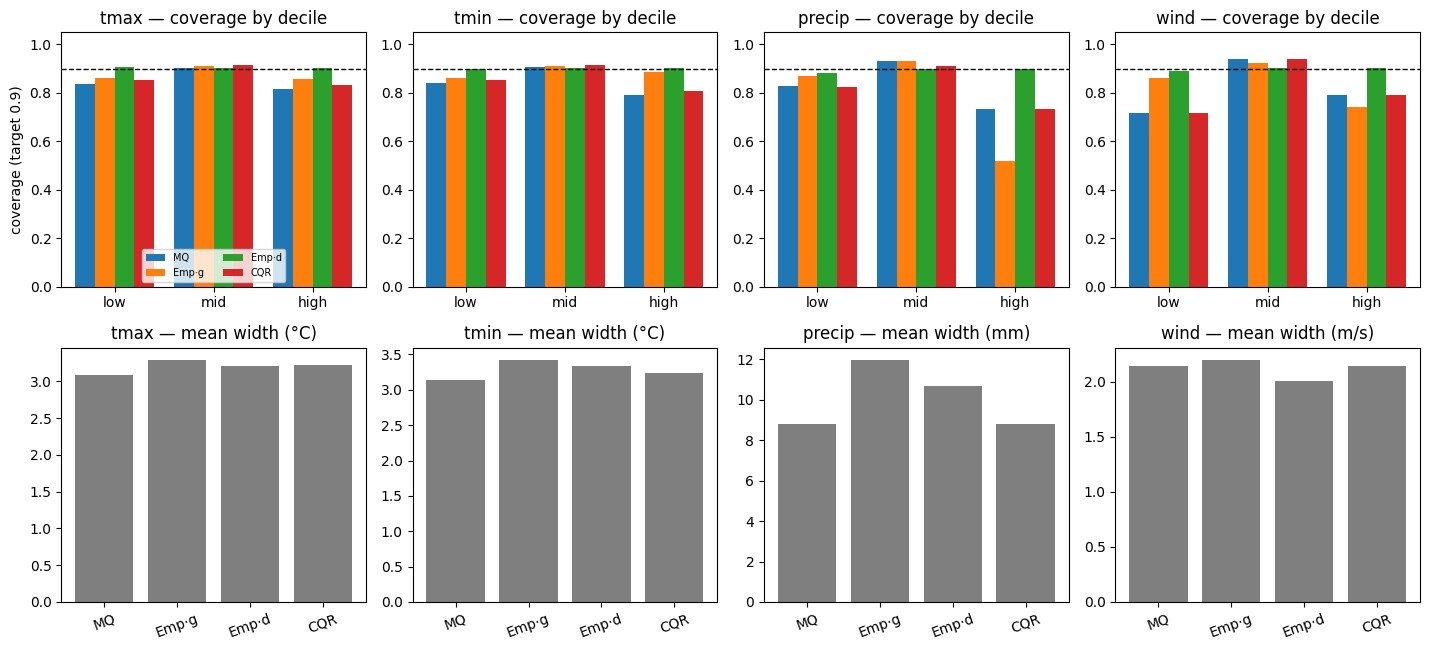

Read it like this:
  • bars near the dashed line in EVERY decile  = well calibrated (CQR / empirical should be).
  • MultiQuantile bars drifting off 0.90, esp. in low/high deciles = no guarantee + thin tails.
  • among equally-covered methods, the SHORTEST mean width wins (sharper = more useful).
  • adaptivity shows up as MQ/CQR width changing across deciles vs Emp·g being flat.


In [40]:
# === 12b. The tradeoff, drawn: calibration (coverage) vs sharpness (width) ===
method_order = ['MultiQuantile', 'Empirical (global)', 'Empirical (decile)', 'CQR']
short_name = {'MultiQuantile': 'MQ', 'Empirical (global)': 'Emp·g',
         'Empirical (decile)': 'Emp·d', 'CQR': 'CQR'}
deciles  = ['low', 'mid', 'high']
fig, axes = plt.subplots(2, len(VARS), figsize=(3.6 * len(VARS), 6.6))
for var_idx, var in enumerate(VARS):
    var_name = var['name']; var_cov = coverage_table[coverage_table['var'] == var_name].set_index('method')
    ax_cov = axes[0, var_idx]; x = np.arange(len(deciles)); bar_width = 0.2
    for method_idx, method in enumerate(method_order):
        ax_cov.bar(x + (method_idx - 1.5) * bar_width, [var_cov.loc[method, f'cov_{decile}'] for decile in deciles], bar_width, label=short_name[method])
    ax_cov.axhline(NOM, color='k', ls='--', lw=1)
    ax_cov.set_xticks(x); ax_cov.set_xticklabels(deciles); ax_cov.set_ylim(0, 1.05)
    ax_cov.set_title(f'{var_name} — coverage by decile')
    if var_idx == 0: ax_cov.set_ylabel(f'coverage (target {NOM})')
    ax_width = axes[1, var_idx]
    ax_width.bar(range(len(method_order)), [var_cov.loc[method, 'width_all'] for method in method_order], color='tab:gray')
    ax_width.set_xticks(range(len(method_order))); ax_width.set_xticklabels([short_name[method] for method in method_order], rotation=20)
    ax_width.set_title(f'{var_name} — mean width ({var["unit"]})')
axes[0, 0].legend(fontsize=7, loc='lower center', ncol=2)
plt.tight_layout(); plt.show()

print('Read it like this:')
print('  • bars near the dashed line in EVERY decile  = well calibrated (CQR / empirical should be).')
print('  • MultiQuantile bars drifting off 0.90, esp. in low/high deciles = no guarantee + thin tails.')
print('  • among equally-covered methods, the SHORTEST mean width wins (sharper = more useful).')
print('  • adaptivity shows up as MQ/CQR width changing across deciles vs Emp·g being flat.')

## 12c–d. Width up close — distribution of widths, and width vs forecast value

Two views of *sharpness/adaptivity* across all four variables and all four methods,
straight from the `BANDS` dict §12a built:

- **§12c** — histogram of the per-row 90% interval width. Empirical (global) is a single
  spike (one width for everything); Empirical (decile) is up to three spikes; MultiQuantile
  and CQR spread out (width follows the features). CQR = MultiQuantile shifted by +2·Q.
- **§12d** — full width *distribution* per HRES-forecast-value bin (boxplots), as a grid of
  variable × method. Adaptive methods' boxes grow/shift with the value; Empirical (global)
  is a flat line (zero spread).

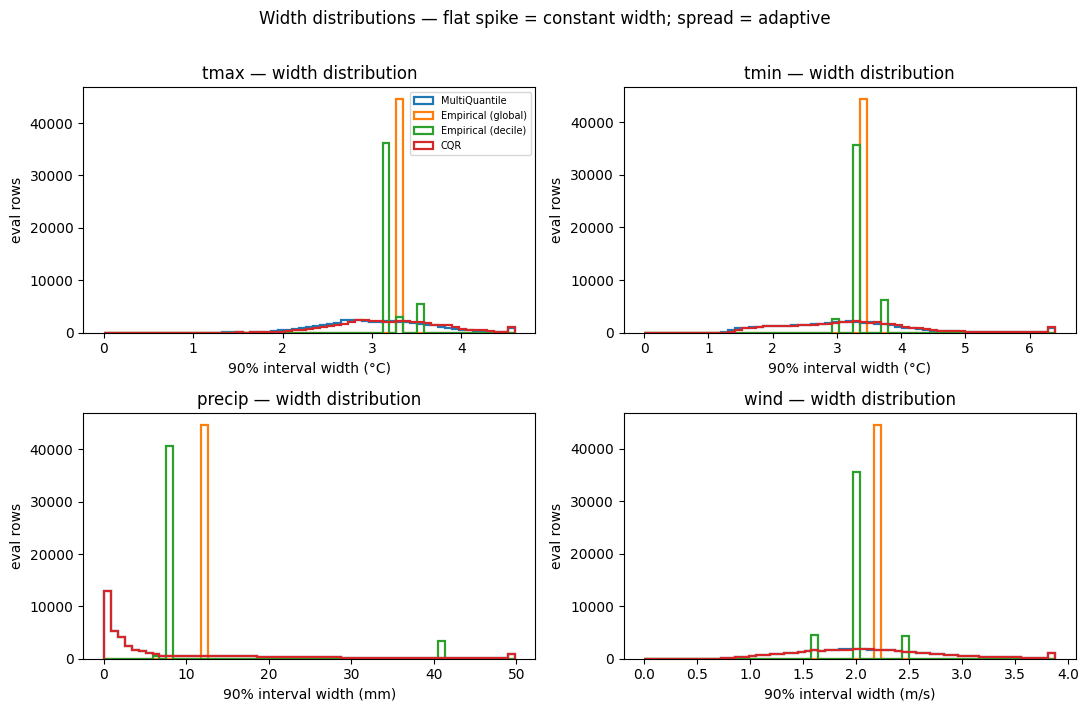

Emp·global = one spike (same width everywhere) | Emp·decile = up to 3 spikes (per decile)
MultiQuantile / CQR = continuous spread (width follows features); CQR = MQ shifted by +2·Q


In [41]:
# === 12c. Histogram of band widths — per variable, overlaid by method ===
ORDER  = ['MultiQuantile', 'Empirical (global)', 'Empirical (decile)', 'CQR']
COLORS = {'MultiQuantile': 'tab:blue', 'Empirical (global)': 'tab:orange',
          'Empirical (decile)': 'tab:green', 'CQR': 'tab:red'}
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, var in zip(axes.ravel(), VARS):
    var_name = var['name']; band = bands_by_var[var_name]
    widths = {method: np.clip(upper - lower, 0, None) for method, (lower, upper) in band['methods'].items()}
    width_cap = float(np.percentile(np.concatenate(list(widths.values())), 99))  # clip tail for readability
    bins = np.linspace(0, width_cap if width_cap > 0 else 1, 60)
    for method in ORDER:
        ax.hist(np.clip(widths[method], 0, width_cap), bins=bins, histtype='step', lw=1.6,
                color=COLORS[method], label=method)
    ax.set_title(f'{var_name} — width distribution')
    ax.set_xlabel(f'90% interval width ({band["unit"]})'); ax.set_ylabel('eval rows')
axes[0, 0].legend(fontsize=7)
fig.suptitle('Width distributions — flat spike = constant width; spread = adaptive', y=1.01)
plt.tight_layout(); plt.show()
print('Emp·global = one spike (same width everywhere) | Emp·decile = up to 3 spikes (per decile)')
print('MultiQuantile / CQR = continuous spread (width follows features); CQR = MQ shifted by +2·Q')

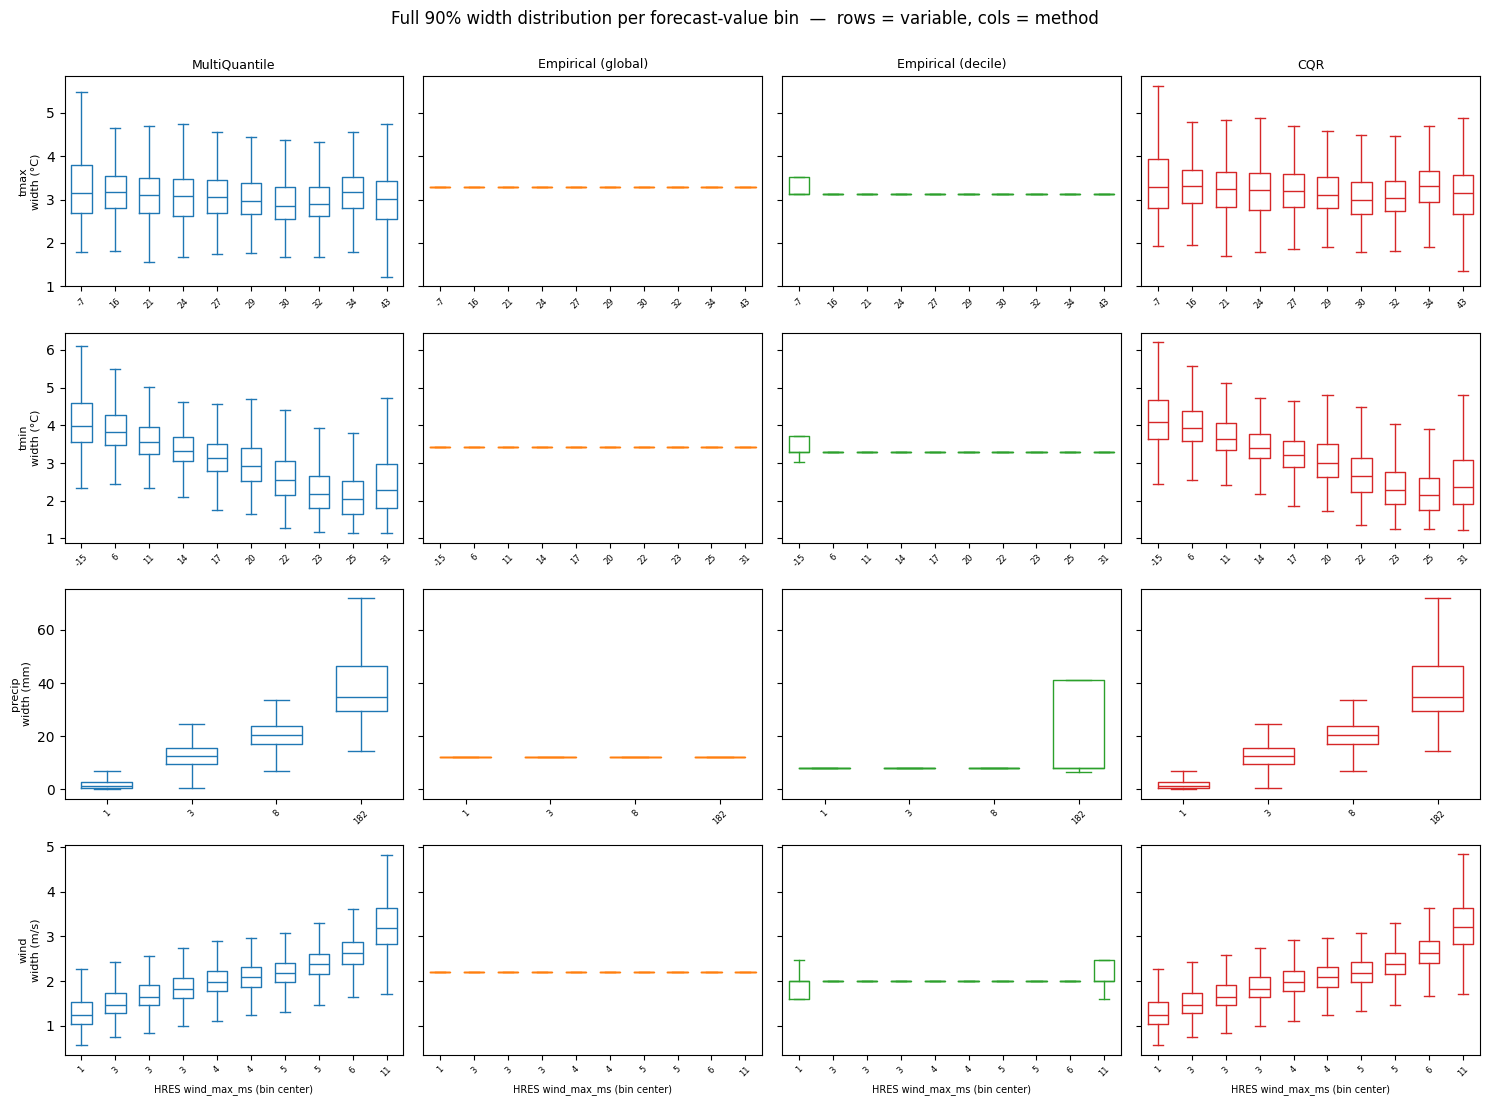

Each box = spread of widths in that value bin. Emp·global = flat line (constant width);
Emp·decile = few discrete levels; MultiQuantile / CQR = boxes that grow/shift with the value.


In [42]:
# === 12d. Width DISTRIBUTION vs forecast value — boxplots, grid of variable x method ===
# Boxes show the full spread of the 90% interval width within each equal-count value bin.
ORDER  = ['MultiQuantile', 'Empirical (global)', 'Empirical (decile)', 'CQR']
COLORS = {'MultiQuantile': 'tab:blue', 'Empirical (global)': 'tab:orange',
          'Empirical (decile)': 'tab:green', 'CQR': 'tab:red'}
NBINS = 10
fig, axes = plt.subplots(len(VARS), len(ORDER), figsize=(15, 11),
                         sharex='row', sharey='row')
for var_idx, var in enumerate(VARS):
    var_name = var['name']; band = bands_by_var[var_name]; hres_vals = band['hres']
    bin_edges = np.unique(np.quantile(hres_vals, np.linspace(0, 1, NBINS + 1)))   # equal-count value bins
    n_bins = len(bin_edges) - 1
    bin_idx = np.clip(np.digitize(hres_vals, bin_edges[1:-1]), 0, n_bins - 1)
    bin_labels = [f'{0.5*(bin_edges[b]+bin_edges[b+1]):.0f}' for b in range(n_bins)]  # bin-center value
    for method_idx, method in enumerate(ORDER):
        ax = axes[var_idx, method_idx]
        lower, upper = band['methods'][method]; width = np.clip(upper - lower, 0, None)
        width_by_bin = [width[bin_idx == b] for b in range(n_bins)]
        color = COLORS[method]
        ax.boxplot(width_by_bin, showfliers=False, widths=0.6,
                   medianprops=dict(color=color), boxprops=dict(color=color),
                   whiskerprops=dict(color=color), capprops=dict(color=color))
        ax.set_xticks(range(1, n_bins + 1)); ax.set_xticklabels(bin_labels, rotation=45, fontsize=6)
        if var_idx == 0: ax.set_title(method, fontsize=9)
        if method_idx == 0: ax.set_ylabel(f'{var_name}\nwidth ({band["unit"]})', fontsize=8)
        if var_idx == len(VARS) - 1: ax.set_xlabel(f'HRES {var["col"]} (bin center)', fontsize=7)
fig.suptitle('Full 90% width distribution per forecast-value bin  —  rows = variable, cols = method',
             y=1.0)
plt.tight_layout(); plt.show()
print('Each box = spread of widths in that value bin. Emp·global = flat line (constant width);')
print('Emp·decile = few discrete levels; MultiQuantile / CQR = boxes that grow/shift with the value.')